In [1]:
from pathlib import Path
from src import config
import cv2
import numpy as np
from src.court_detector import CourtDetector
from src.utils.helpers import crop_center_img, load_process_params, lines_from_gray_img
from src.utils.filters import filter_horizontal_lines
from src.config import set_debug_mode, get_debug_mode
from cvgeomkit.utils.helpers import read_image_as_numpyimage, load_json
from cvgeomkit.utils.plotting import display_img
from cvgeomkit.geometry.intersections import compute_intersections
from cvgeomkit.geometry.lines import transform_line

In [2]:
get_debug_mode()
set_debug_mode(True)

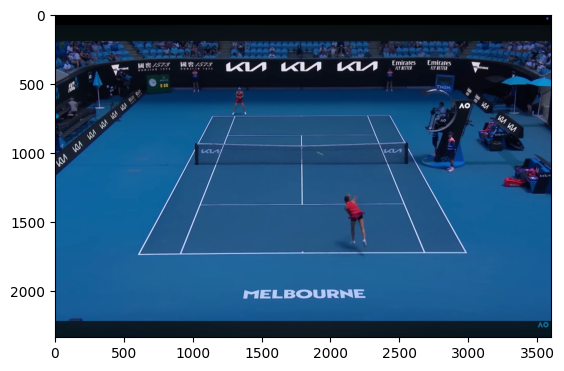

In [4]:
path = '/Users/polymorvic/development/tennis-court-detection/bad_frames/bad_frame_0001.png' # '../data/pics/05_10.png'     # '../data/pics/10_06.png'
# path = '../data/pics/skip/skip_01_35.png'
img = read_image_as_numpyimage(path)

# img =cv2.resize(img, (img.shape[1]//2, img.shape[0]//2))
display_img(img)

In [85]:
# roi = crop_center_img(img)[0][900:1000]  # [750:850]    # [900:1000]
# display_img(roi)

In [86]:
# out = cv2.bilateralFilter(roi, 15, 30, 30)
# display_img(out)

#### scan for baseline

In [5]:
params = load_process_params('../config/process_params.config.json')

crop_center_ratio = params.detection_params.basic.crop_center_ratio
roi_h_px = params.detection_params.basic.roi_h_px
step_px = params.detection_params.basic.step_px

warmup = params.detection_params.baseline.warmup
canny_lower_thresh = params.detection_params.baseline.canny_lower_thresh
canny_upper_thresh = params.detection_params.baseline.canny_upper_thresh
hough_thresh = params.detection_params.baseline.hough_thresh
min_line_len_ratio = params.detection_params.baseline.min_line_len_ratio
min_line_len_ensure_ratio = params.detection_params.baseline.min_line_len_ensure_ratio
min_line_gap_px = params.detection_params.baseline.min_line_gap_px
h_line_slope_tolerance = params.detection_params.baseline.h_line_slope_tolerance
h_delta_ensure_px = params.detection_params.baseline.h_delta_ensure_px

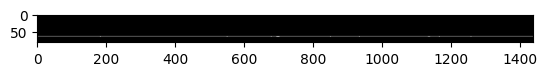

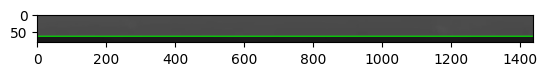

[y = 0.0 * x + 63.0]
[y = 0.0 * x + 63.0]
baseline global
y = 0.0 * x + 2221.0


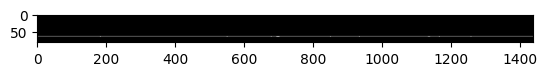

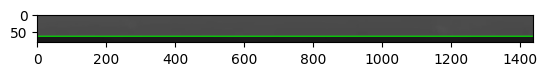

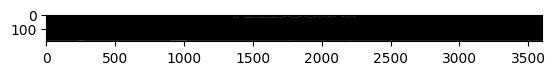

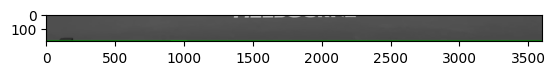

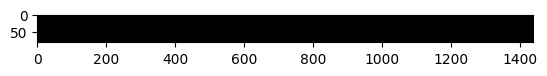

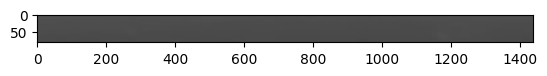

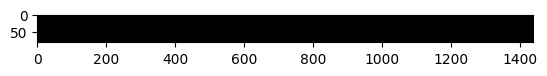

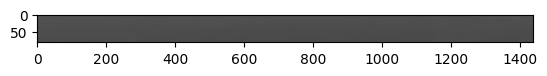

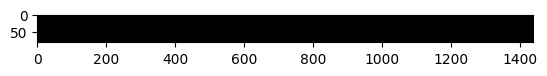

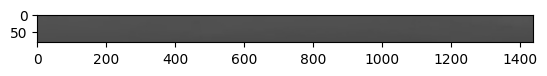

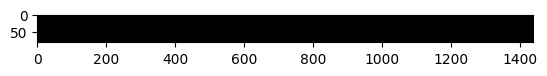

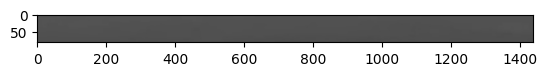

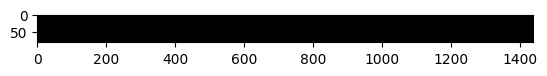

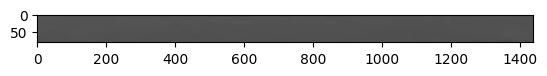

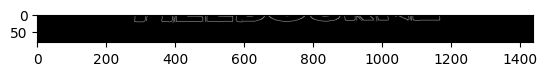

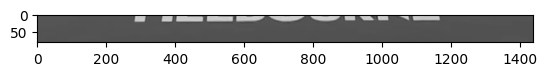

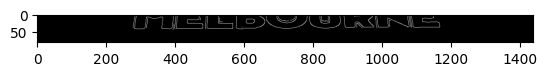

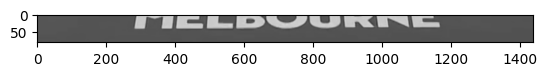

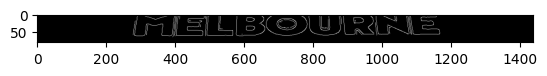

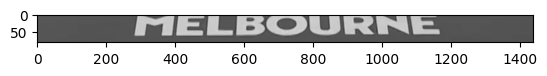

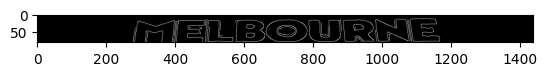

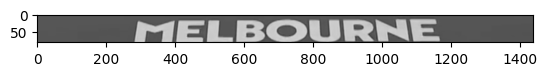

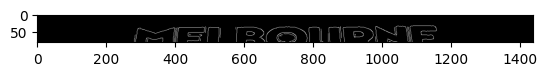

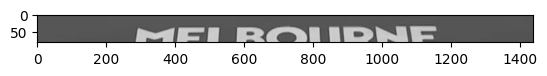

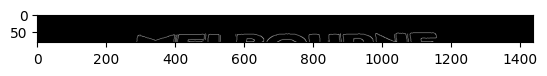

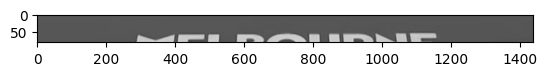

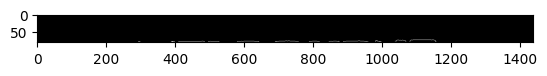

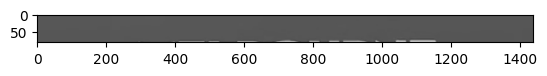

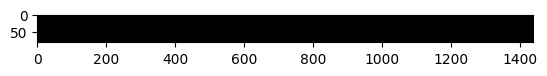

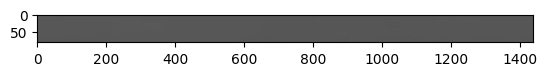

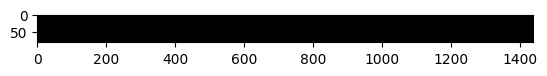

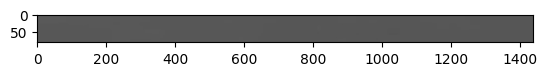

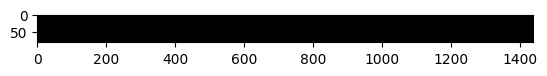

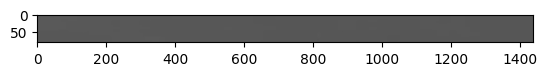

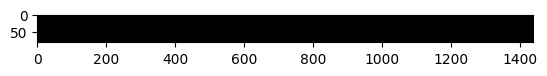

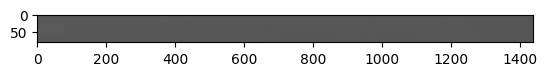

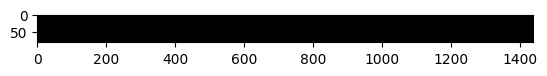

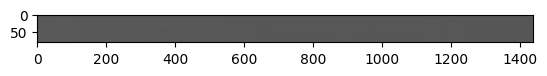

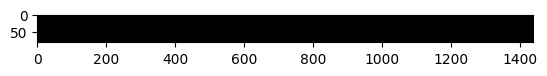

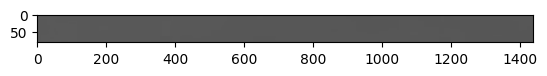

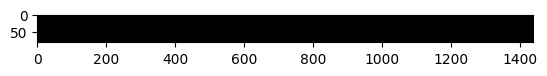

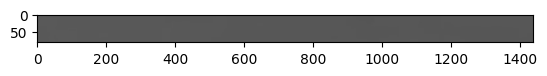

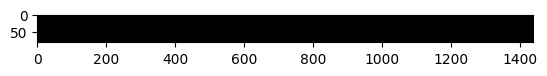

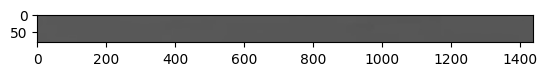

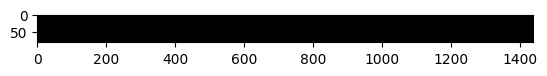

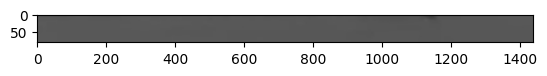

[y = 0.0 * x + 0.0]
[y = 0.0 * x + 0.0]
baseline global
y = 0.0 * x + 1738.0


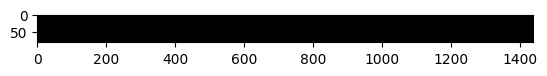

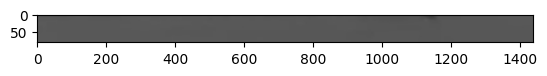

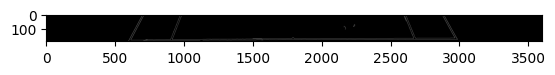

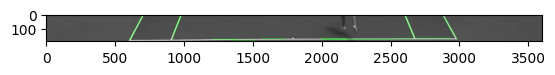

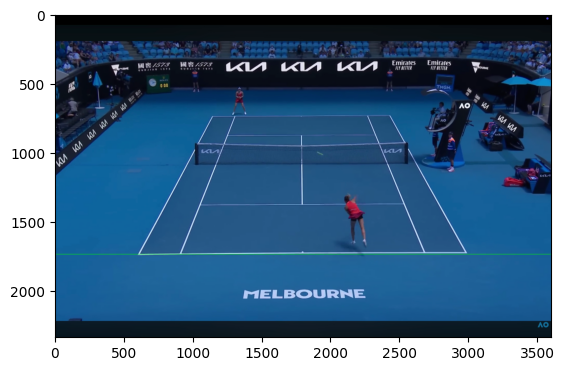

In [6]:
detector = CourtDetector(img, crop_center_ratio, roi_h_px, step_px)
baseline, sidelines = detector.scan_for_baseline(
    warmup,
    canny_lower_thresh,
    canny_upper_thresh,
    hough_thresh,
    min_line_len_ratio,
    min_line_len_ensure_ratio,
    min_line_gap_px,
    h_line_slope_tolerance
)

if baseline is not None:
    p1, p2 = baseline.limit_to_img(img)
    img_copy = img.copy()
    cv2.line(img_copy, p1, p2, (0, 255, 0), 2)
    display_img(img_copy)

In [154]:
img.shape

(1078, 1918, 3)

In [155]:
points = []
for sideline in sidelines:
    inter = baseline.intersection(sideline, img)
    points.append(inter.point)


In [156]:
sorted_points = sorted(points, key = lambda point: point.x)
left_point = sorted_points[0]
right_point = sorted_points[-1]
sorted_points

[Point(308, 822),
 Point(314, 822),
 Point(465, 822),
 Point(470, 822),
 Point(1374, 822),
 Point(1379, 822),
 Point(1529, 822),
 Point(1534, 822),
 Point(1917, 822)]

In [157]:
spread = right_point.x - left_point.x

In [160]:
right_point

Point(1917, 822)

In [158]:
spread / 1918

0.8388946819603754

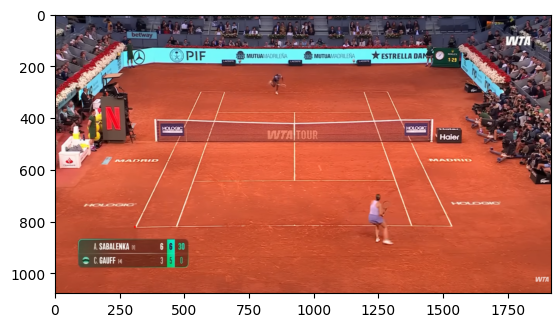

In [161]:
img_copy = img.copy()
cv2.circle(img_copy, left_point, 4, (255,0,0), -1)
cv2.circle(img_copy, right_point, 4, (255,0,0), -1)
display_img(img_copy)

In [162]:
from cvgeomkit.geometry.points import Point

In [163]:
p_c = Point((left_point.x + right_point.x) // 2, left_point.y)

In [164]:
p_c

Point(1112, 822)

In [165]:
from cvgeomkit.geometry.lines import Line
from src.utils.filters import filter_horizontal_lines

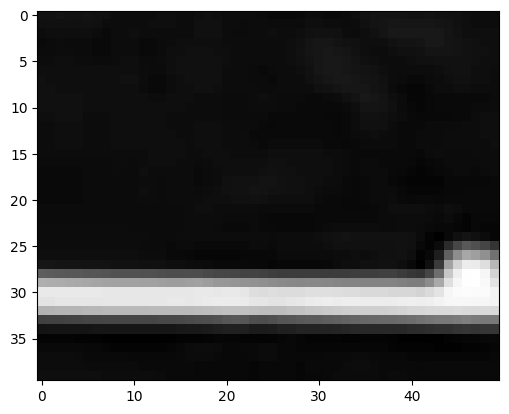

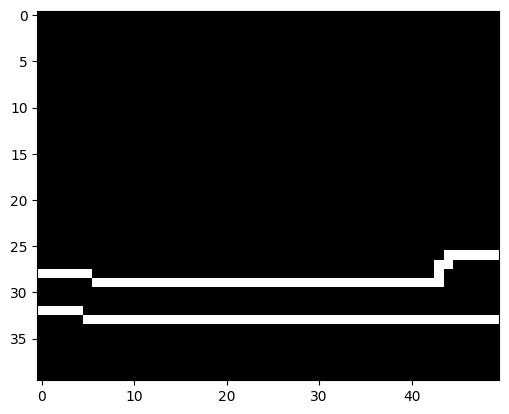

[y = 0.0 * x + 33.0]


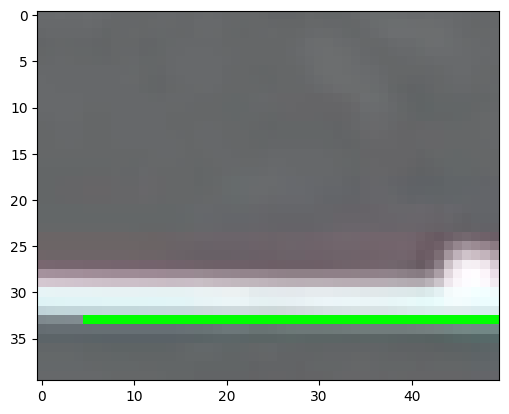

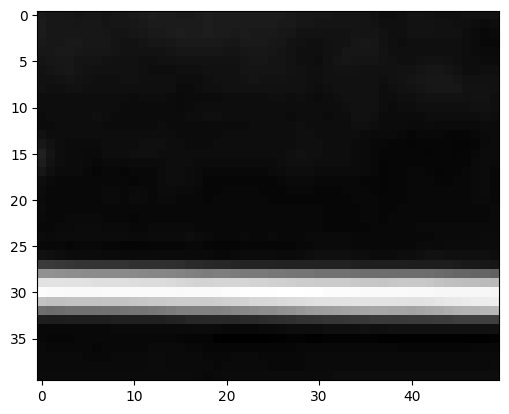

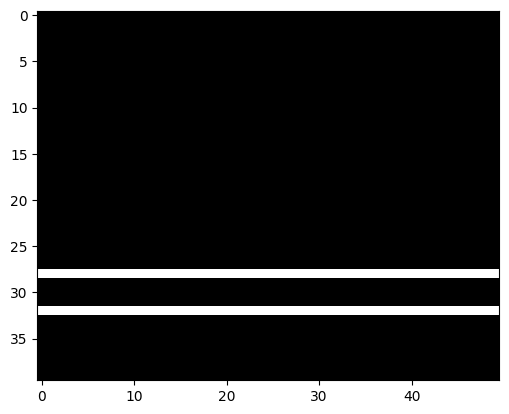

[y = 0.0 * x + 28.0, y = 0.0 * x + 32.0]


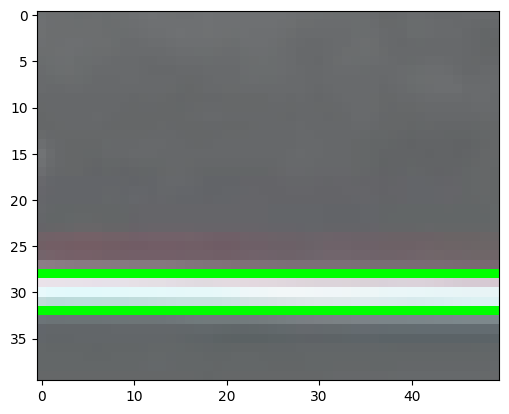

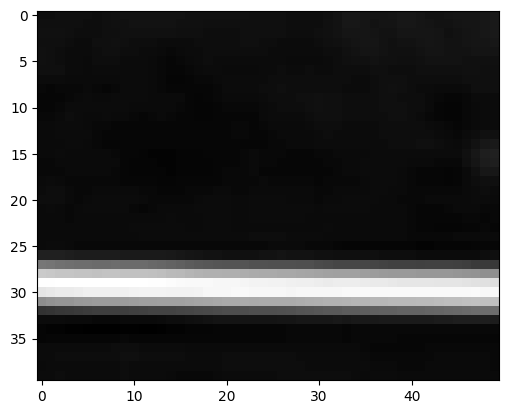

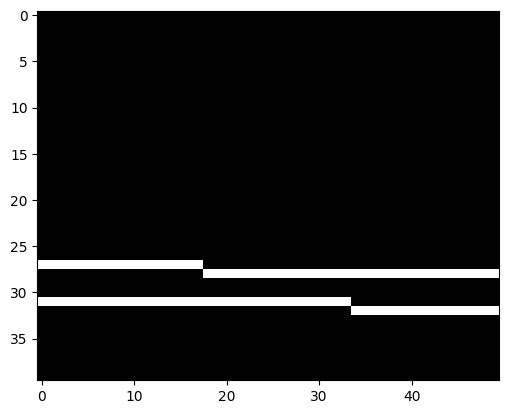

[y = 0.0 * x + 31.0]


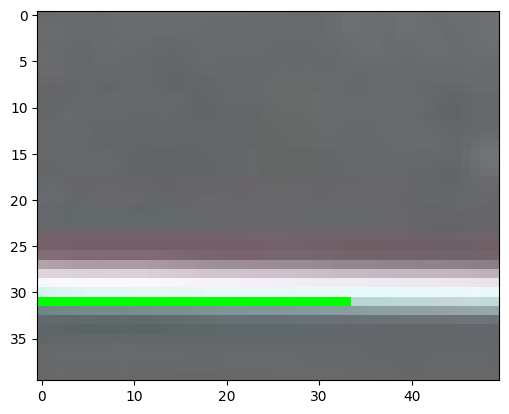

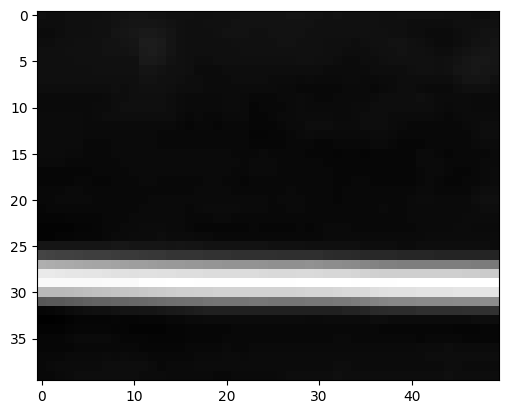

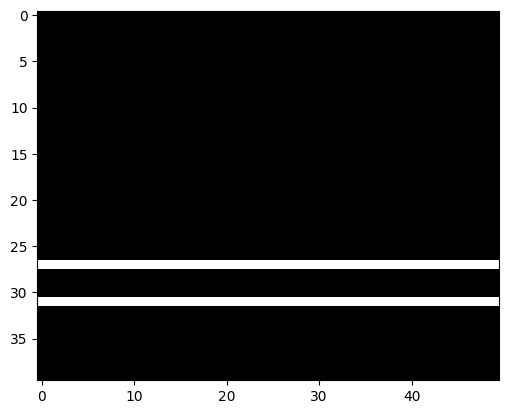

[y = 0.0 * x + 27.0, y = 0.0 * x + 31.0]


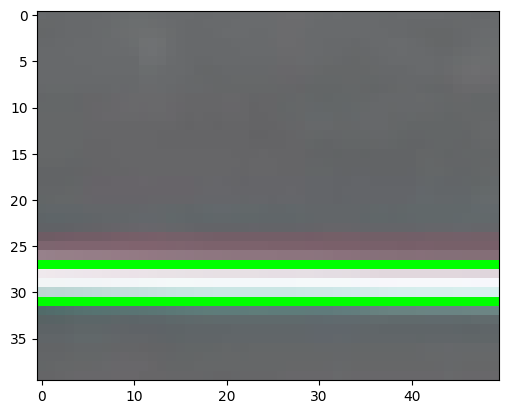

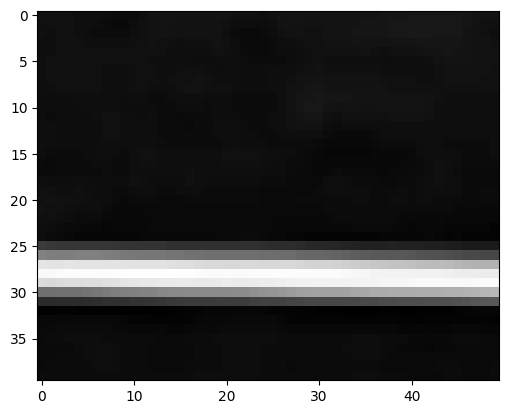

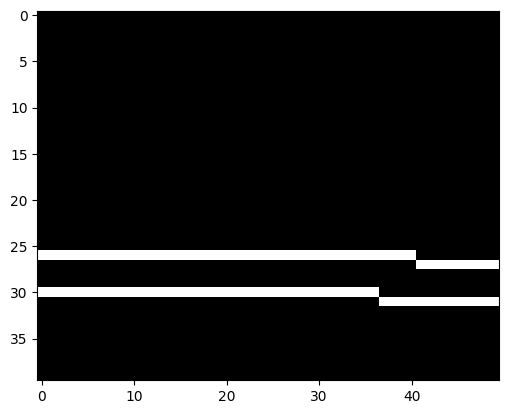

[y = 0.0 * x + 26.0, y = 0.0 * x + 30.0]


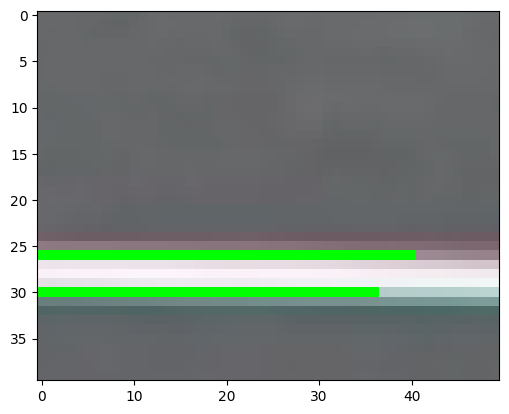

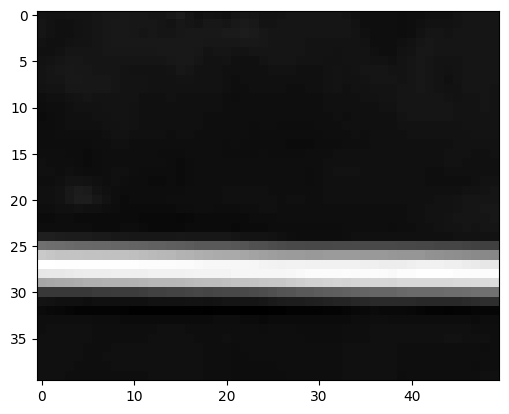

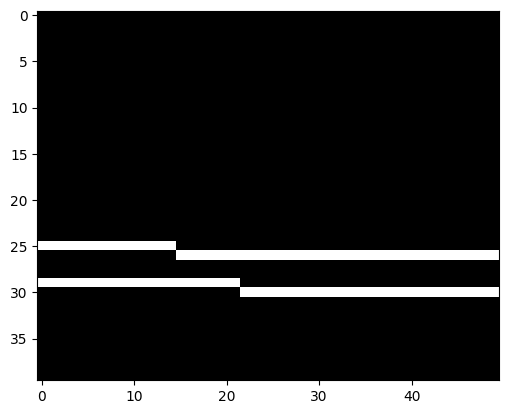

[y = 0.0 * x + 29.0]


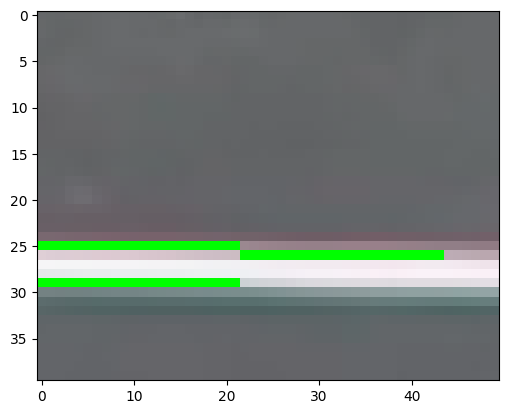

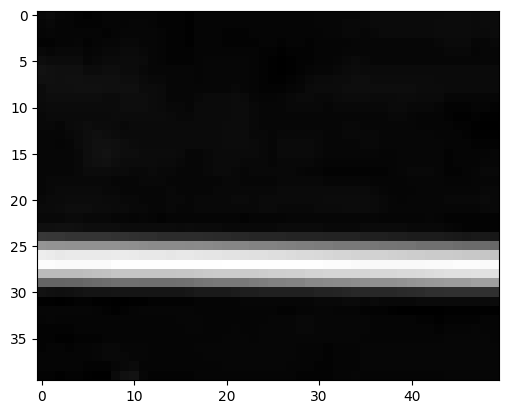

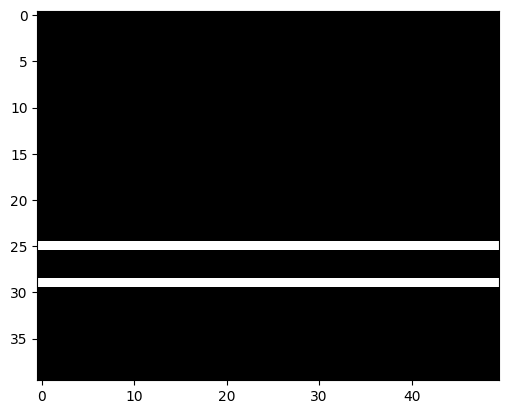

[y = 0.0 * x + 25.0, y = 0.0 * x + 29.0]


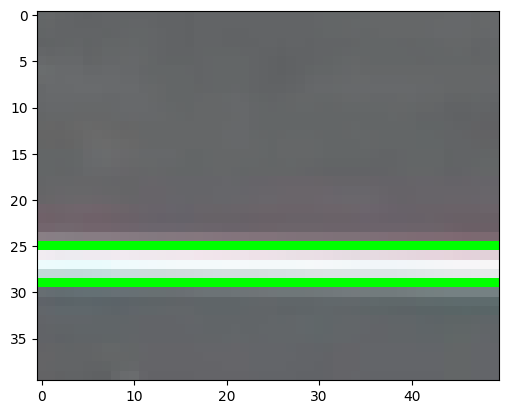

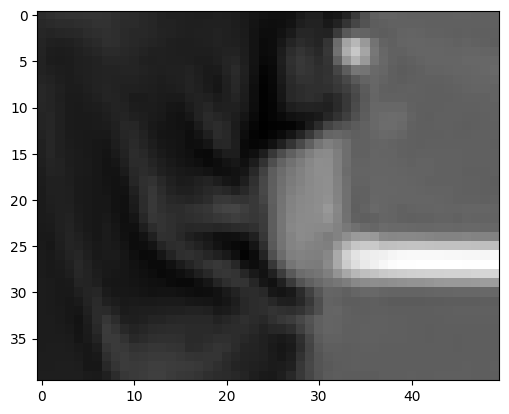

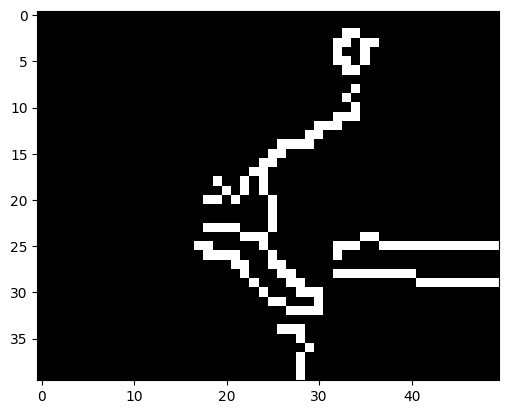

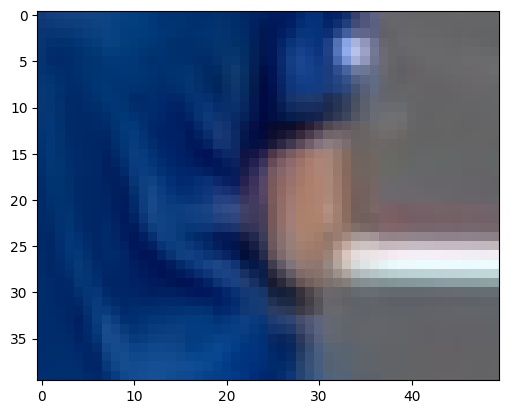

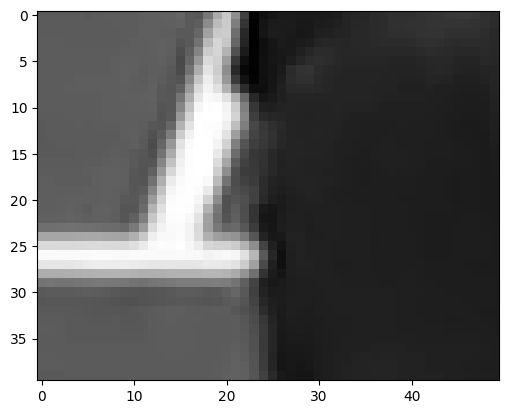

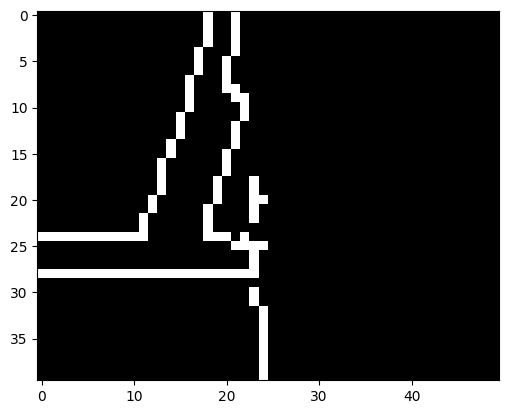

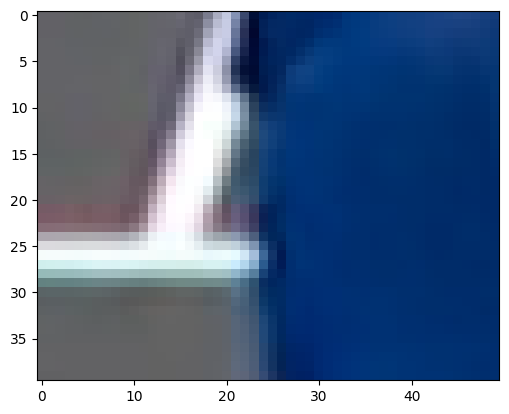

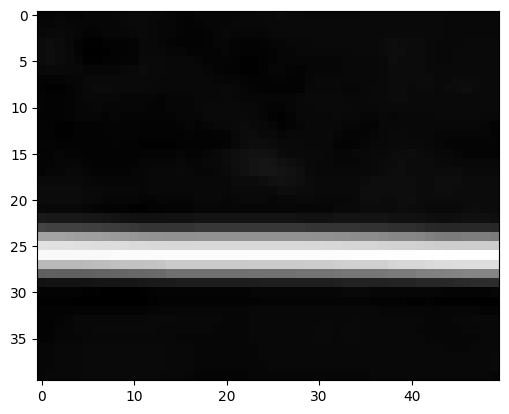

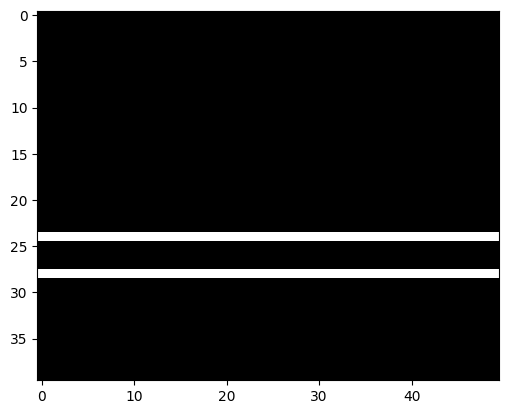

[y = 0.0 * x + 24.0, y = 0.0 * x + 28.0]


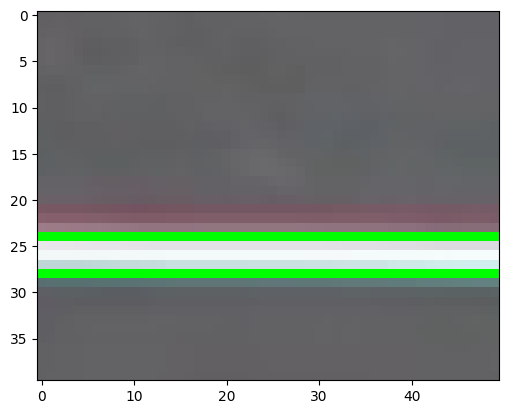

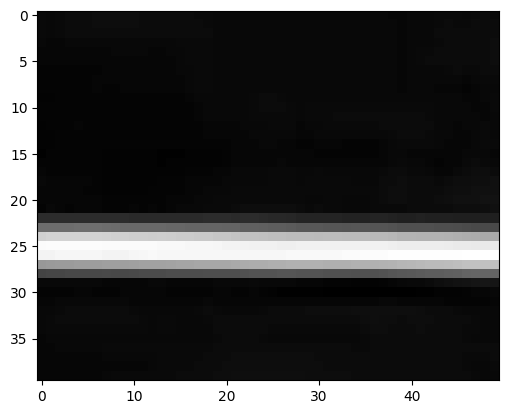

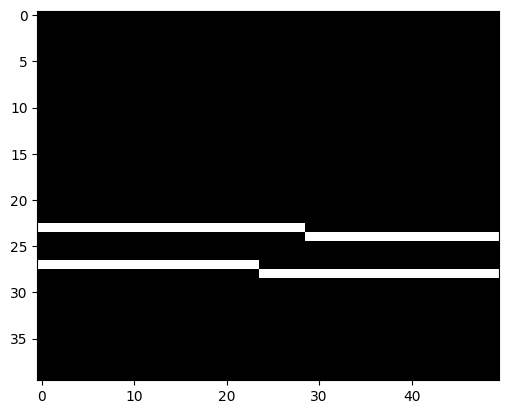

[y = 0.0 * x + 24.0, y = 0.0 * x + 27.0]


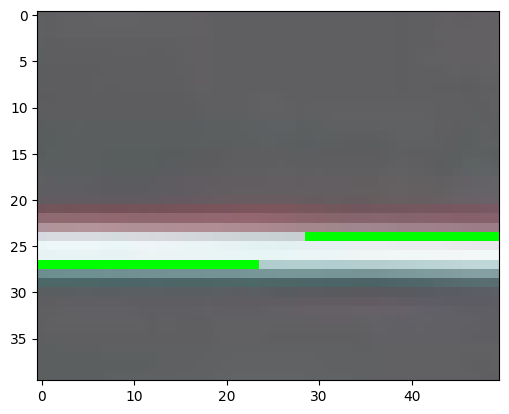

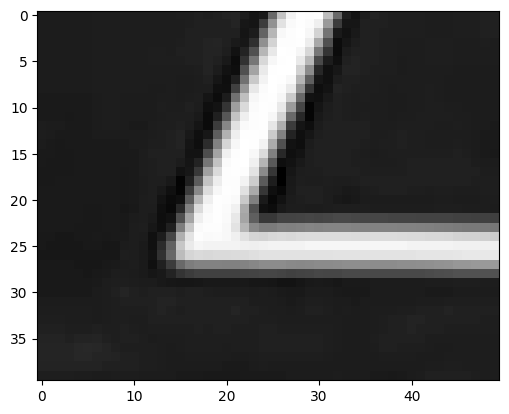

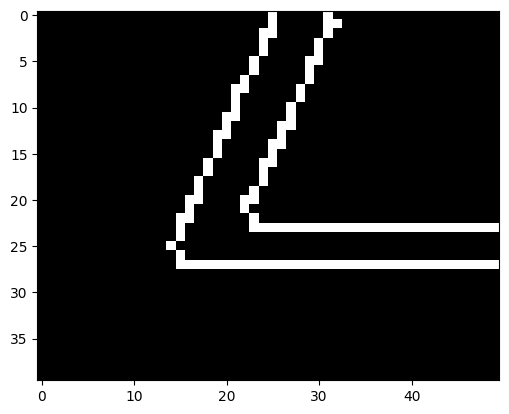

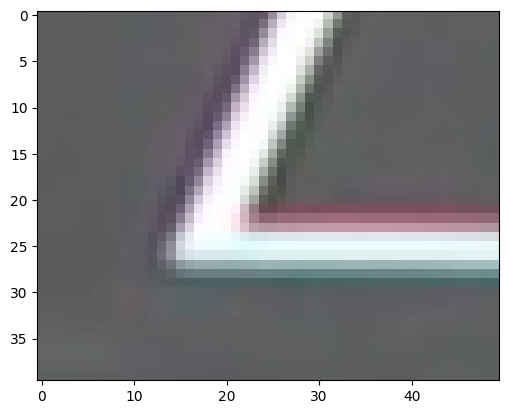

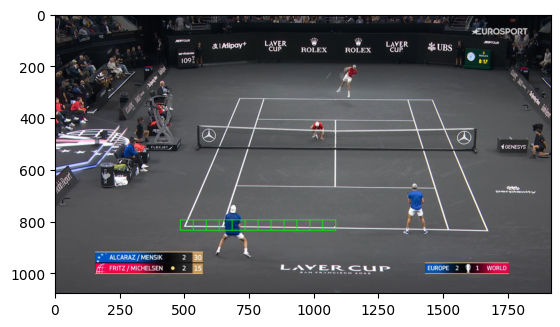

In [102]:
step = 50
x_left = p_c.x - step
x_right = p_c.x
img_copy = img.copy()
h_delta = 20
lines = []
while x_right > left_point.x:

    crop = img[p_c.y - h_delta: p_c.y + h_delta, x_left: x_right]
    crop_gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)

    edges = cv2.Canny(crop_gray, 100, 200)
    segments = cv2.HoughLinesP(edges, 1, np.pi / 180, int(step * 0.8), int(step * 0.4), int(step * 0.1))

    display_img(crop_gray)
    display_img(edges)

    crop_copy = crop.copy()
    sub_lines = []
    if segments is not None:
        for line in segments:
            x1, y1, x2, y2 = line[0]
            cv2.line(crop_copy, (x1, y1), (x2, y2), (0, 255, 0), 1)
            line = Line.from_hough_segment(line[0])
            sub_lines.append(line)
    
    # wez lienie horyzontalne
    sub_lines = filter_horizontal_lines(sub_lines)
    if sub_lines:
        print(sorted(sub_lines, key = lambda line: line.intercept))
        bottom_line = sorted(sub_lines, key = lambda line: line.intercept)[-1]
        bottom_line_global = transform_line(bottom_line, crop, x_left, p_c.y)
        lines.append(bottom_line_global)
    else:
        lines.append(None)



    display_img(crop_copy)

    cv2.rectangle(img_copy, (x_left, p_c.y - h_delta), (x_right, p_c.y + h_delta), (0, 255, 0), 2)

    x_right = x_left
    x_left -= step

display_img(img_copy)

In [103]:
lines

[y = 0.0 * x + 848.0,
 y = 0.0 * x + 847.0,
 y = 0.0 * x + 846.0,
 y = 0.0 * x + 846.0,
 y = 0.0 * x + 845.0,
 y = 0.0 * x + 844.0,
 y = 0.0 * x + 844.0,
 None,
 None,
 y = 0.0 * x + 843.0,
 y = 0.0 * x + 842.0,
 None]

In [108]:
from typing import Literal

In [166]:
def traverse_horizontal_line(
    img: np.ndarray,
    p_left: Point,
    p_right: Point,
    direction: Literal['left', 'right'],
    step = 50,
    h_delta = 20,
):
    p_c = Point((p_left.x + p_right.x) // 2, p_left.y)

    if direction =='left':
        x1 = p_c.x - step
        x2 = p_c.x
    else:
        x1 = p_c.x 
        x2 = p_c.x + step
        
    img_copy = img.copy()

    lines = []
    while {'left': x2 > p_left.x, 'right': x1 < p_right.x}[direction]:

        crop = img[p_c.y - h_delta: p_c.y + h_delta, x1: x2]
        crop_gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)

        edges = cv2.Canny(crop_gray, 100, 200)
        segments = cv2.HoughLinesP(edges, 1, np.pi / 180, int(step * 0.8), int(step * 0.4), int(step * 0.1))

        if get_debug_mode():
            display_img(crop_gray)
            display_img(edges)

        crop_copy = crop.copy()
        sub_lines = []
        if segments is not None:
            for line in segments:

                if get_debug_mode():
                    x1_hough, y1_hough, x2_hough, y2_hough = line[0]
                    cv2.line(crop_copy, (x1_hough, y1_hough), (x2_hough, y2_hough), (0, 255, 0), 1)

                line = Line.from_hough_segment(line[0])
                sub_lines.append(line)
        
        sub_lines = filter_horizontal_lines(sub_lines)
        if sub_lines:
            print(sorted(sub_lines, key = lambda line: line.intercept))
            bottom_line = sorted(sub_lines, key = lambda line: line.intercept)[-1]
            bottom_line_global = transform_line(bottom_line, crop, x1, p_c.y)
            lines.append(bottom_line_global)
        else:
            lines.append(None)
    
        if direction == 'left':
            x2 = x1
            x1 -= step
            
        else:
            x1 = x2
            x2 += step

        if get_debug_mode():
            display_img(crop_copy)
            cv2.rectangle(img_copy, (x1, p_c.y - h_delta), (x2, p_c.y + h_delta), (0, 255, 0), 2)

    if get_debug_mode():
        display_img(crop_copy)
        cv2.rectangle(img_copy, (x1, p_c.y - h_delta), (x2, p_c.y + h_delta), (0, 255, 0), 2)
        display_img(img_copy)


In [145]:
def interpolate_lines_intercept(lines: list[Line | None]) -> list[Line]:
    intercepts = np.array([line.intercept if line else np.nan for line in lines])
    nan_indices = np.argwhere(np.isnan(intercepts)).flatten()
    not_nan_indices = np.argwhere(~np.isnan(intercepts)).flatten()

    interpolated = np.interp(nan_indices, not_nan_indices, intercepts[not_nan_indices])
    intercepts[nan_indices] = np.round(interpolated)
    
    return [Line(slope=0, intercept=intercept) for intercept in intercepts]

In [146]:
interpolated_left = interpolate_lines_intercept(lines)

In [147]:
interpolated_left

[y = 0 * x + 848.0,
 y = 0 * x + 847.0,
 y = 0 * x + 846.0,
 y = 0 * x + 846.0,
 y = 0 * x + 845.0,
 y = 0 * x + 844.0,
 y = 0 * x + 844.0,
 y = 0 * x + 844.0,
 y = 0 * x + 843.0,
 y = 0 * x + 843.0,
 y = 0 * x + 842.0,
 y = 0 * x + 842.0]

In [169]:
right_point

Point(1917, 822)

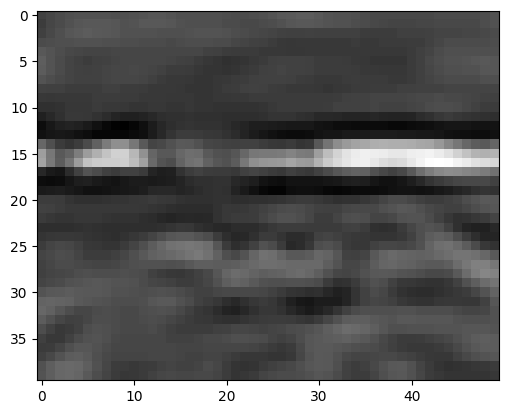

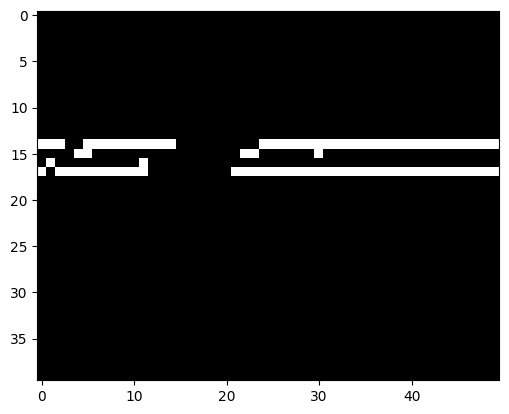

[y = 0.0 * x + 17.0]


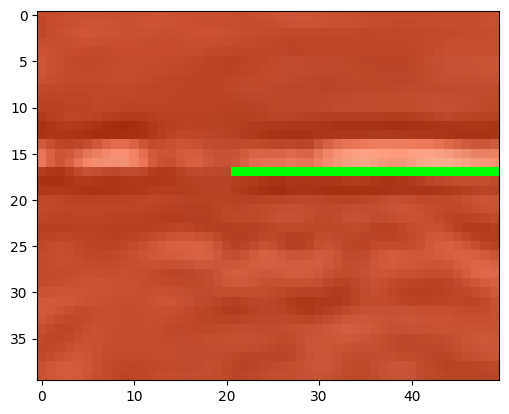

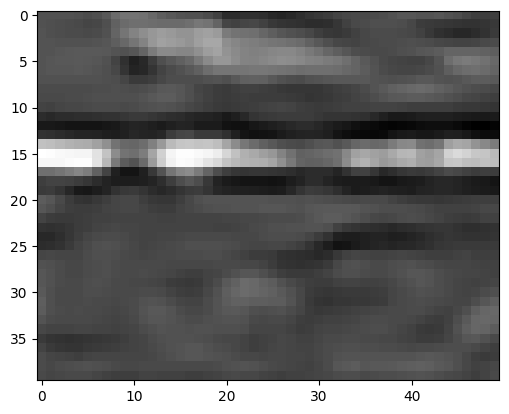

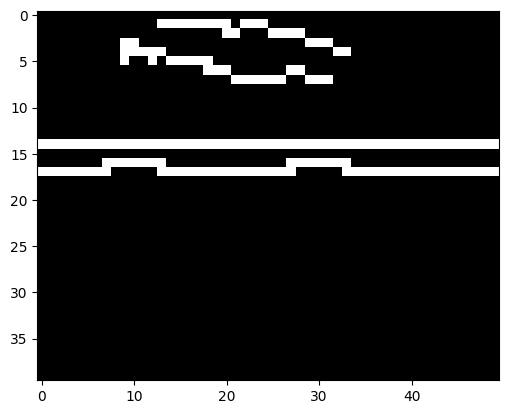

[y = 0.0 * x + 14.0, y = 0.0 * x + 17.0]


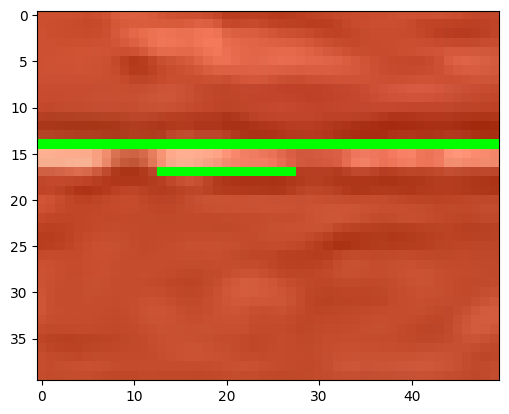

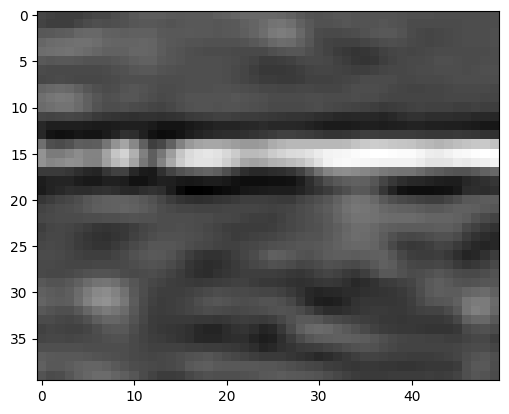

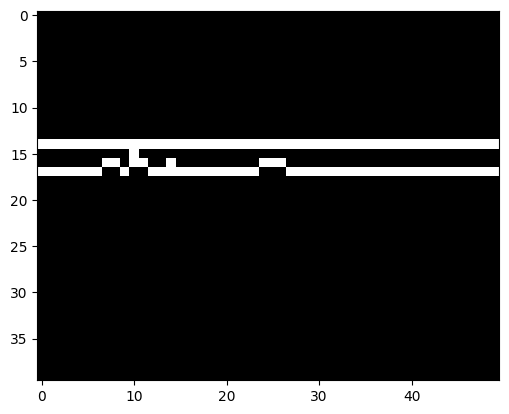

[y = 0.0 * x + 14.0, y = 0.0 * x + 17.0]


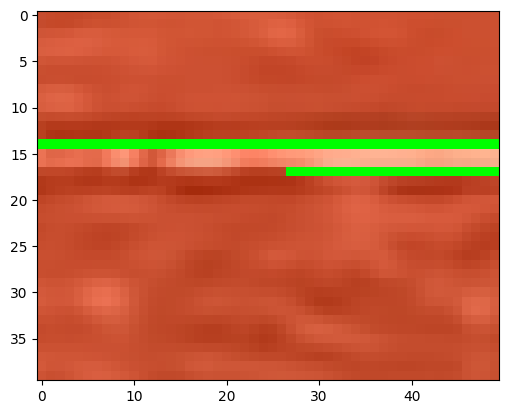

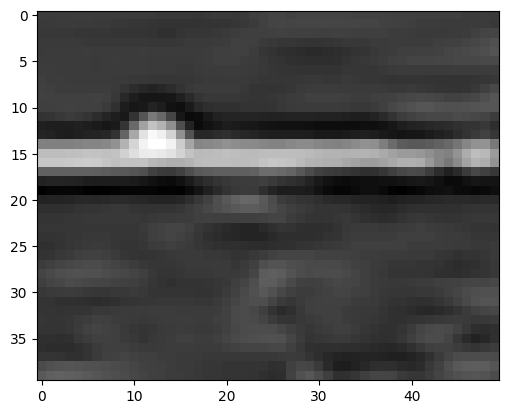

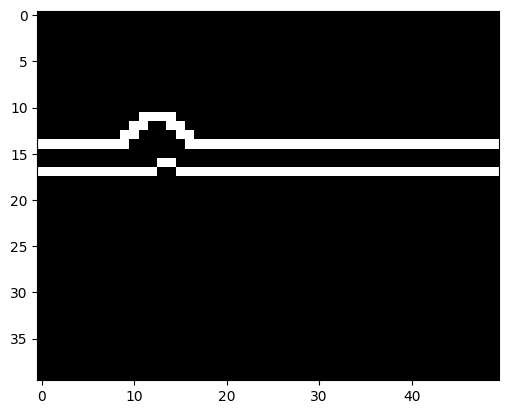

[y = 0.0 * x + 14.0, y = 0.0 * x + 17.0]


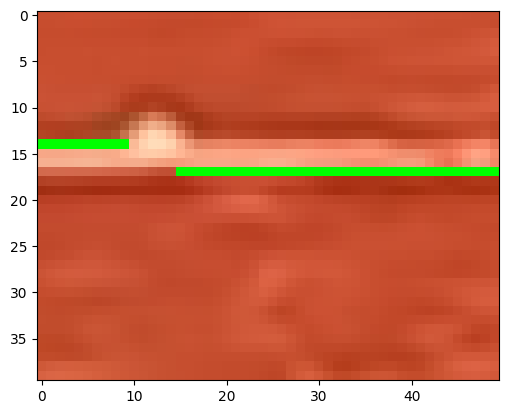

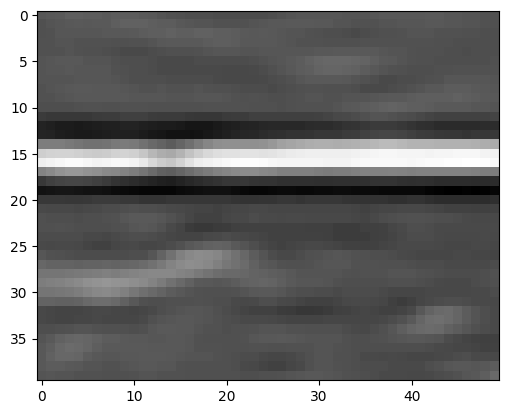

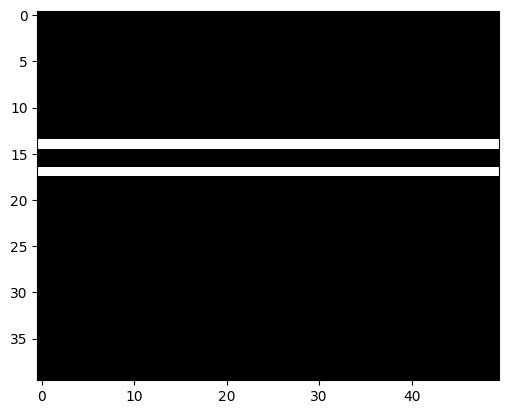

[y = 0.0 * x + 14.0, y = 0.0 * x + 17.0]


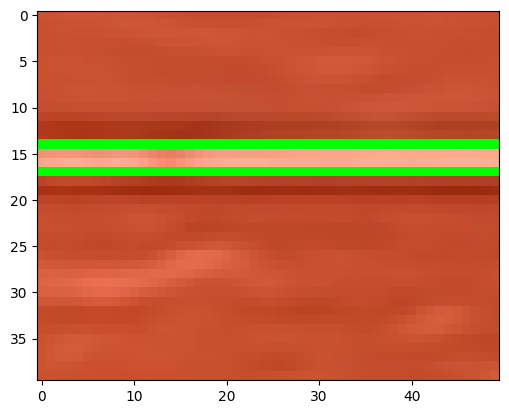

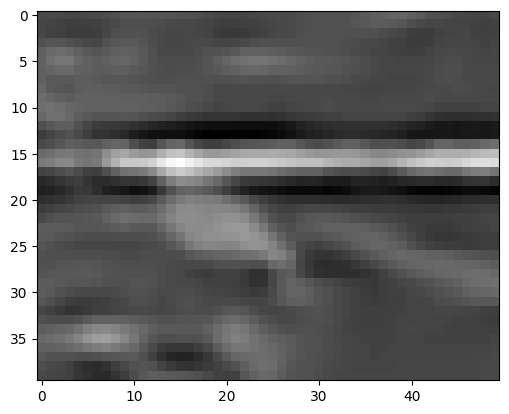

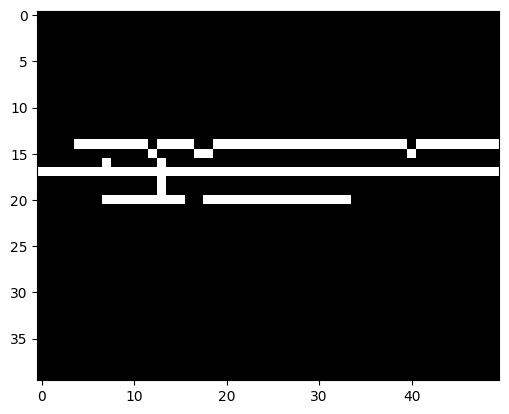

[y = 0.0 * x + 14.0, y = 0.0 * x + 17.0]


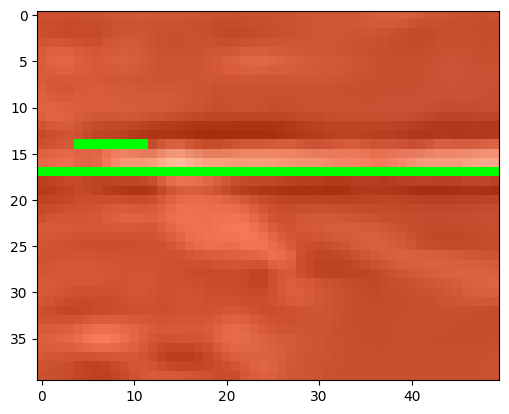

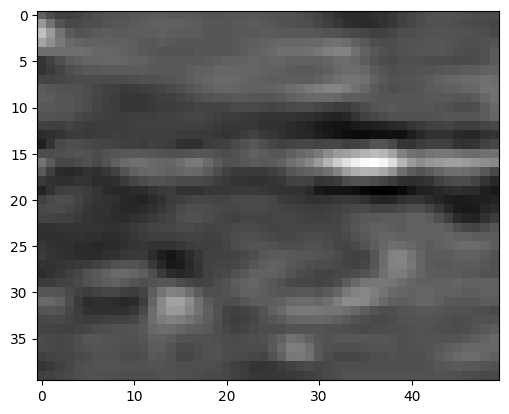

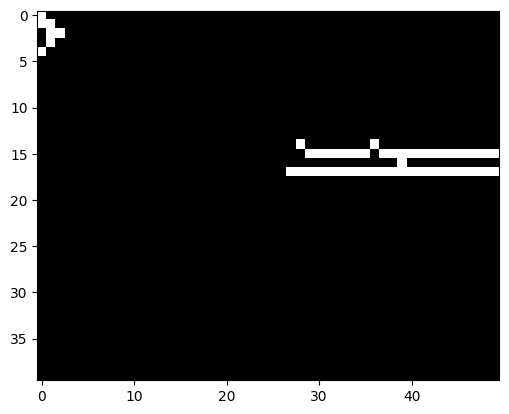

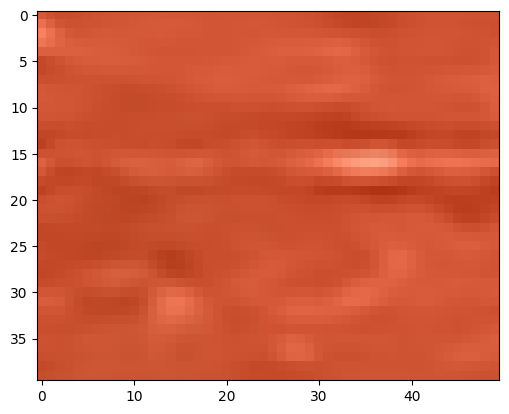

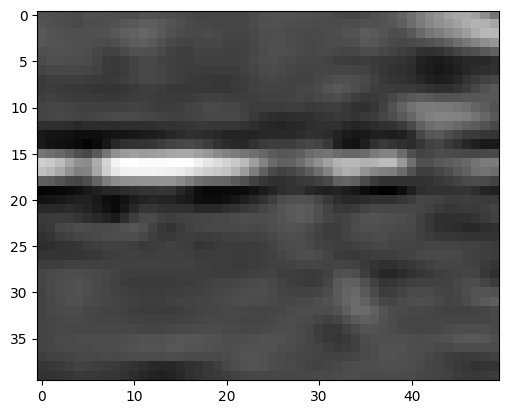

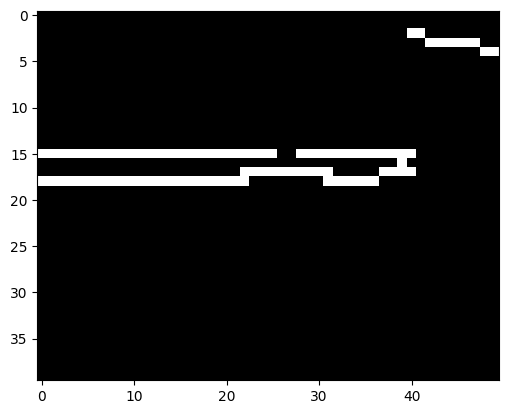

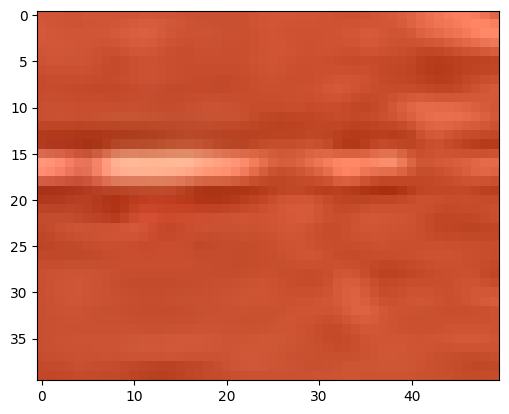

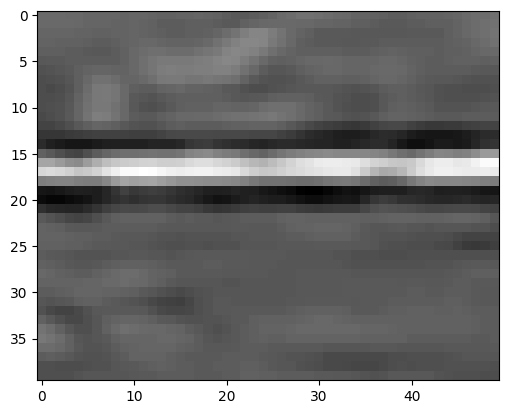

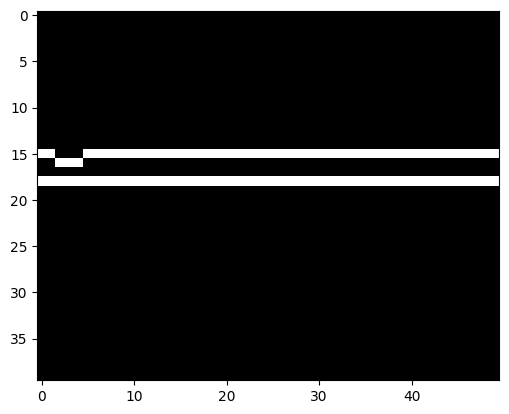

[y = 0.0 * x + 15.0, y = 0.0 * x + 18.0]


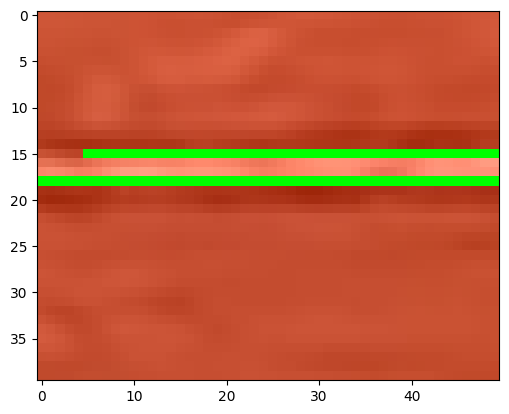

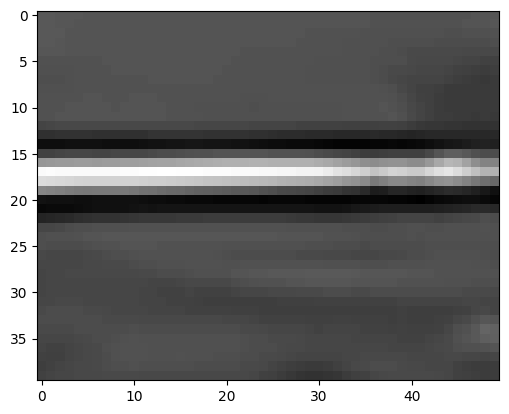

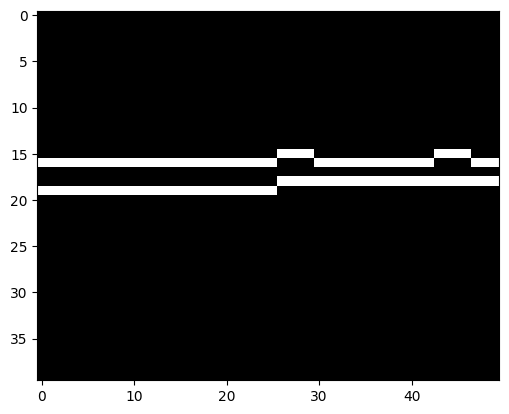

[y = 0.0 * x + 16.0, y = 0.0 * x + 18.0]


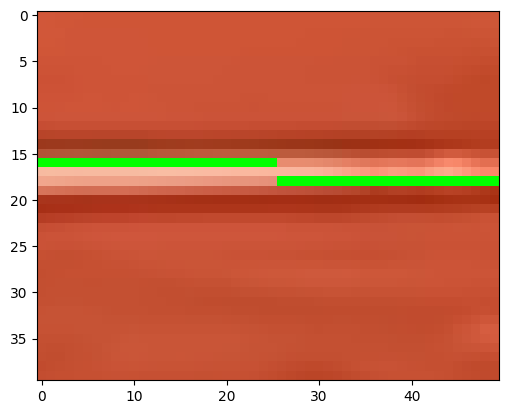

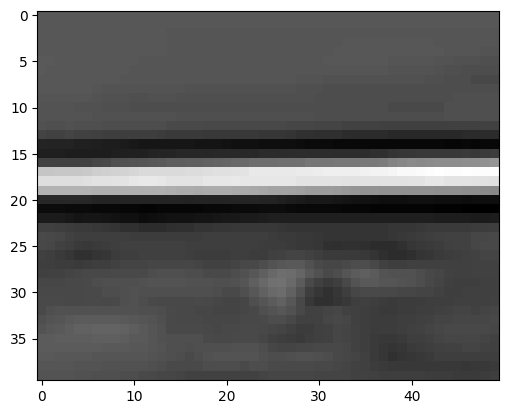

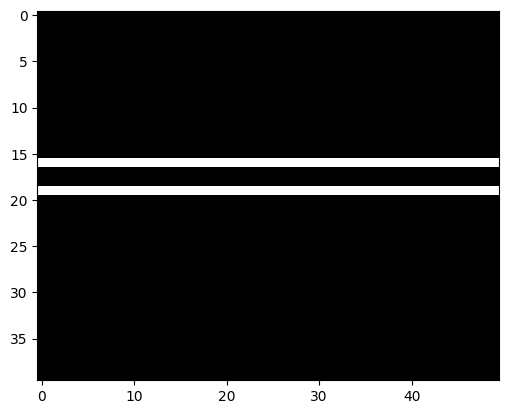

[y = 0.0 * x + 16.0, y = 0.0 * x + 19.0]


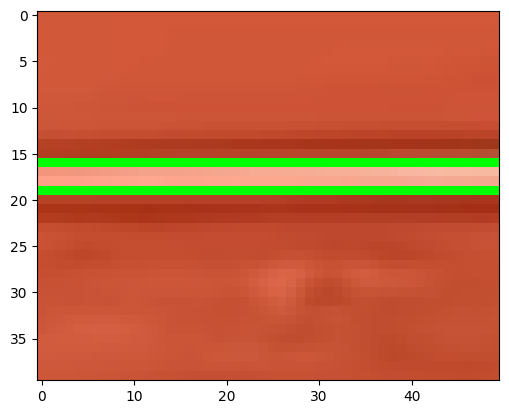

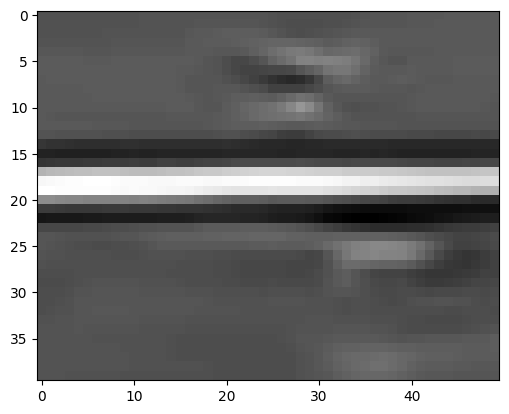

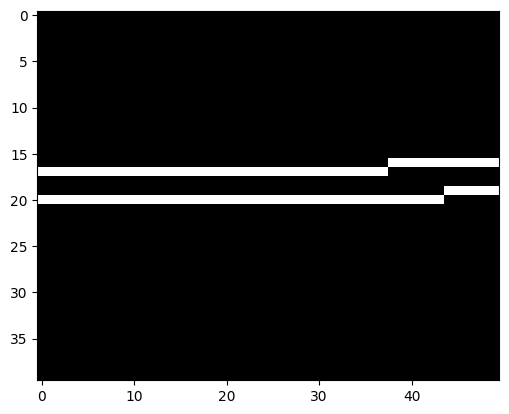

[y = 0.0 * x + 17.0, y = 0.0 * x + 20.0]


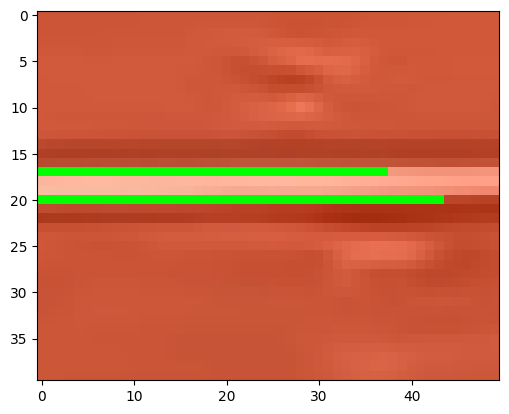

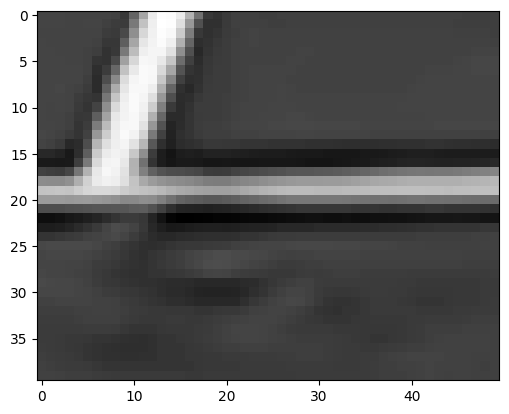

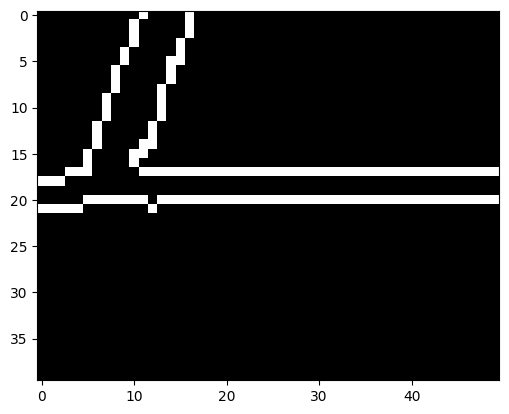

[y = 0.0 * x + 17.0, y = 0.0 * x + 20.0]


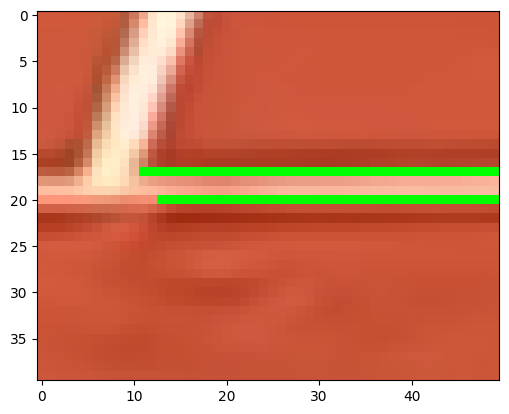

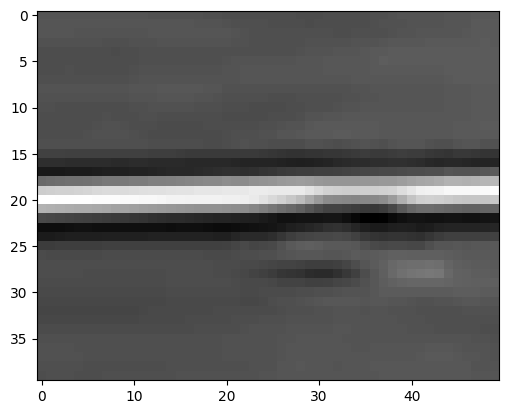

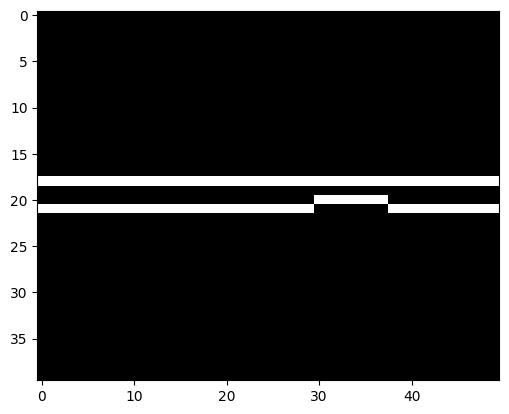

[y = 0.0 * x + 18.0, y = 0.0 * x + 21.0]


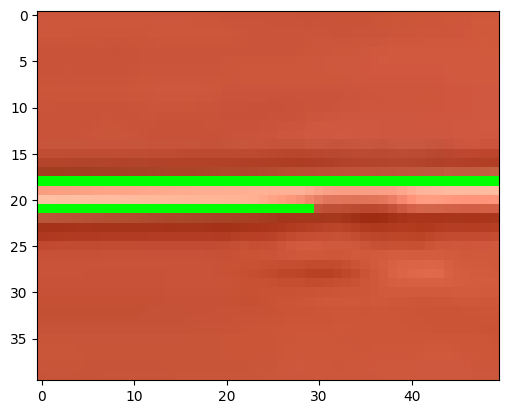

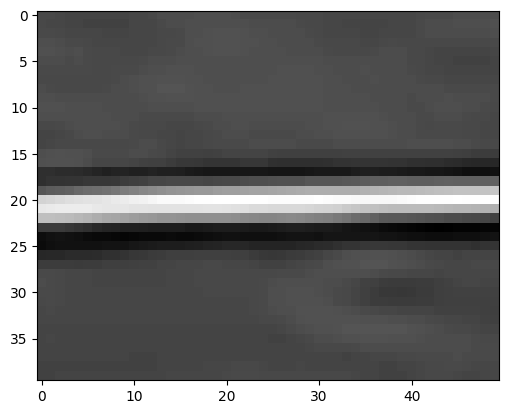

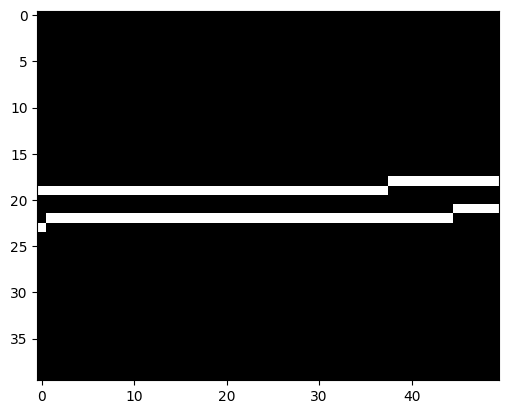

[y = 0.0 * x + 19.0, y = 0.0 * x + 22.0]


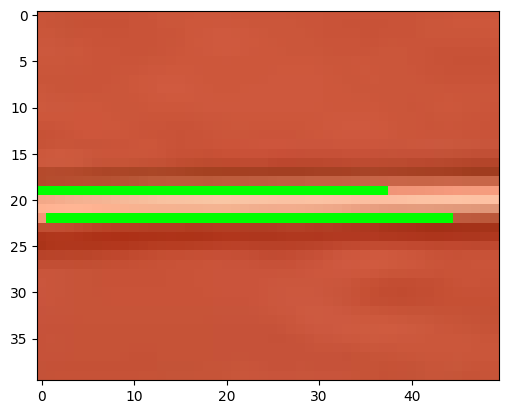

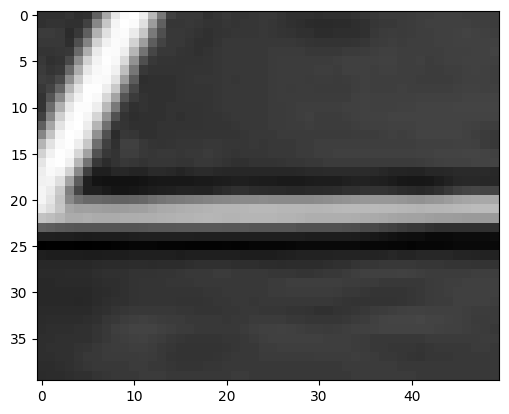

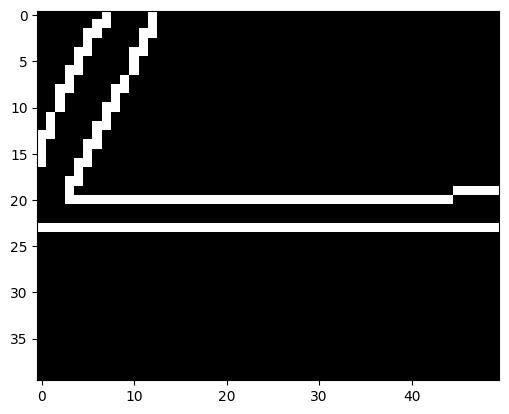

[y = 0.0 * x + 20.0, y = 0.0 * x + 23.0]


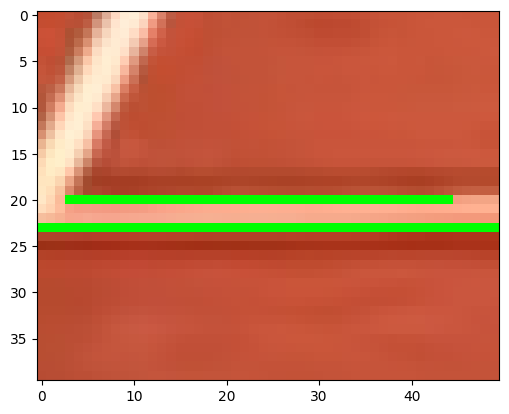

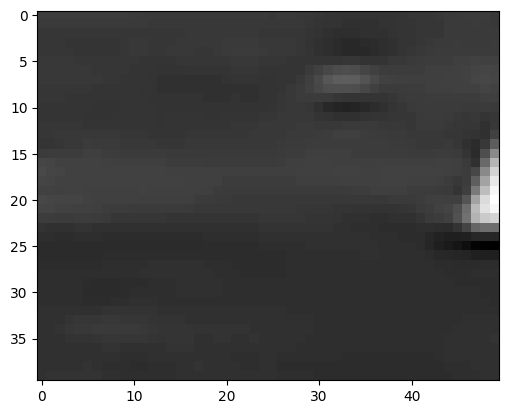

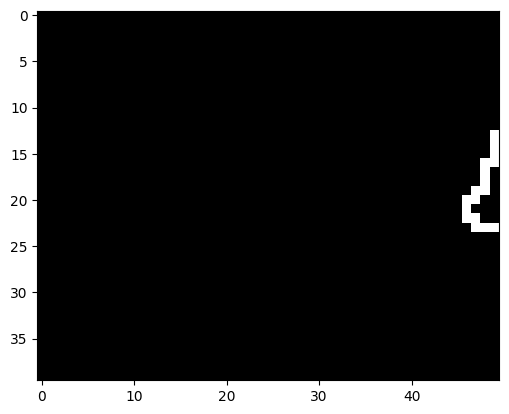

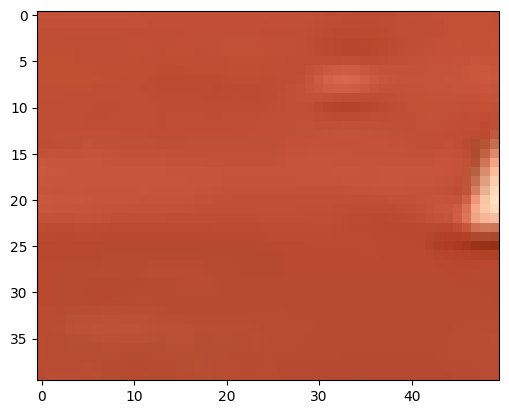

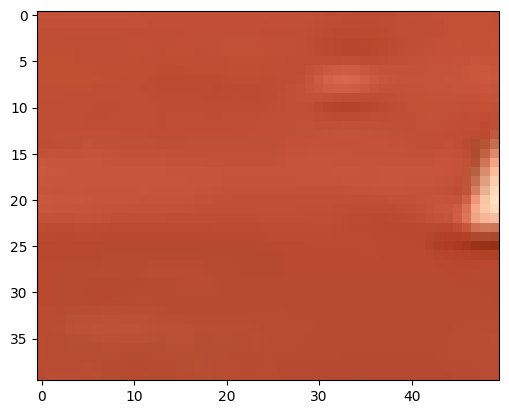

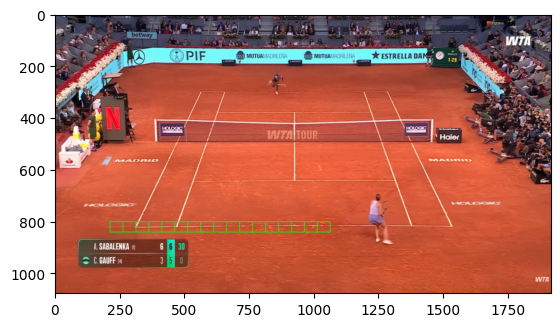

In [167]:
traverse_horizontal_line(img, left_point, right_point, 'left')

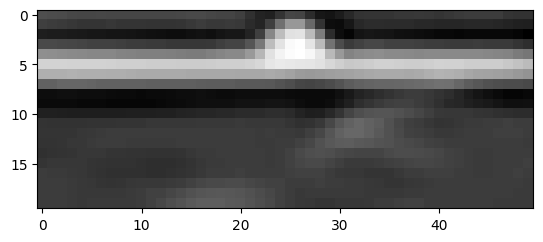

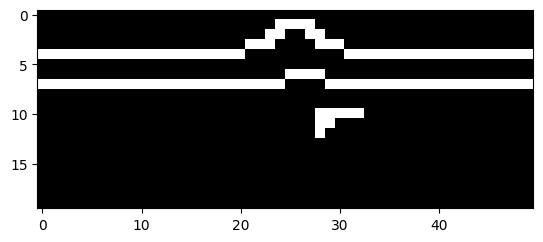

[y = 0.0 * x + 4.0, y = 0.0 * x + 7.0]


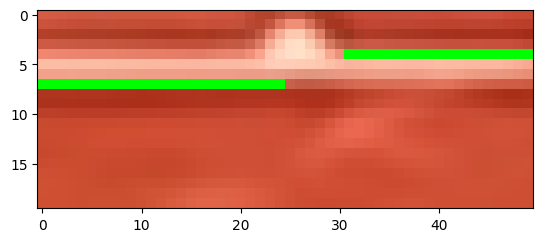

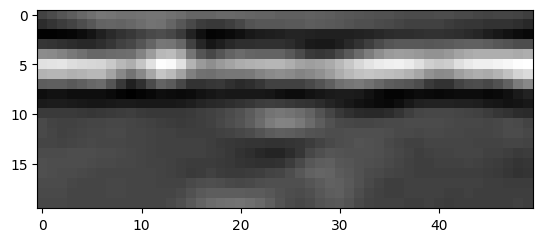

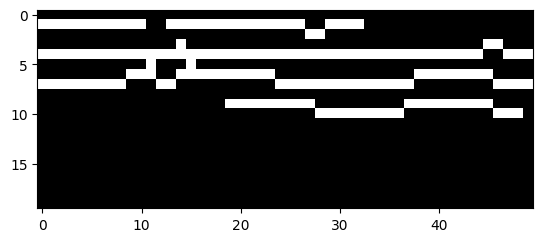

[y = 0.0 * x + 4.0]


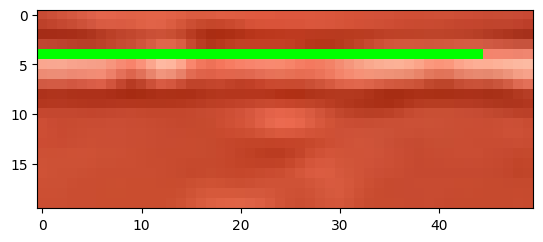

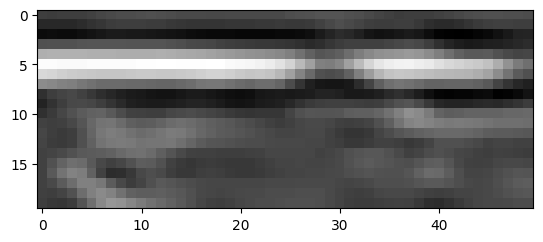

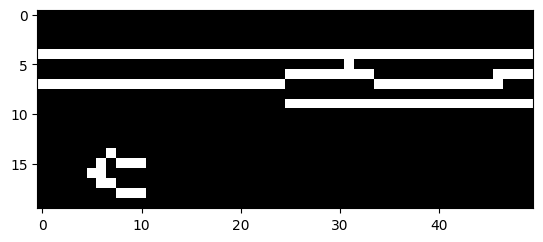

[y = 0.0 * x + 4.0]


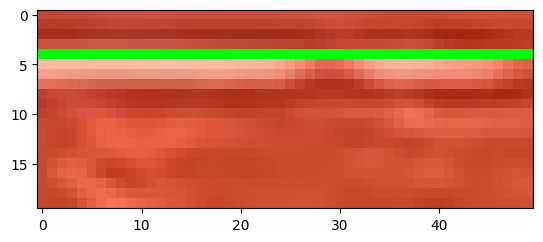

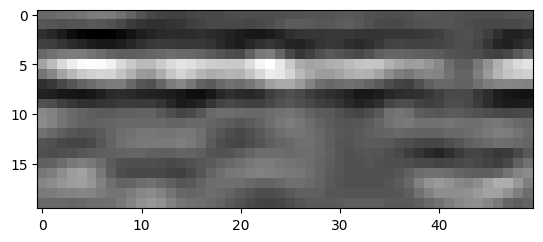

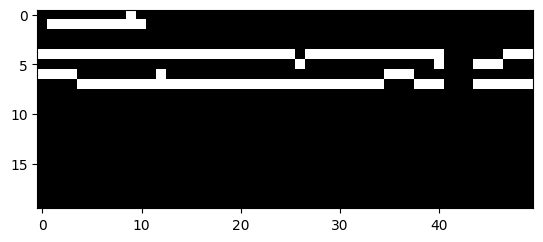

[y = 0.0 * x + 4.0, y = 0.0 * x + 7.0]


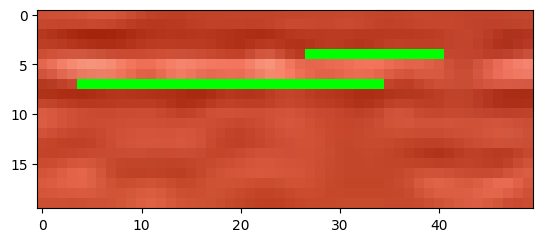

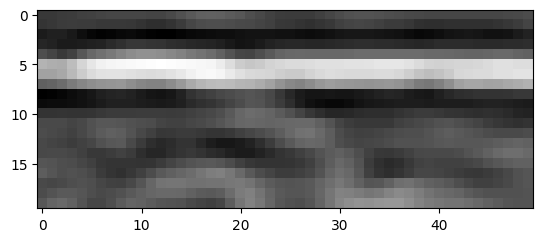

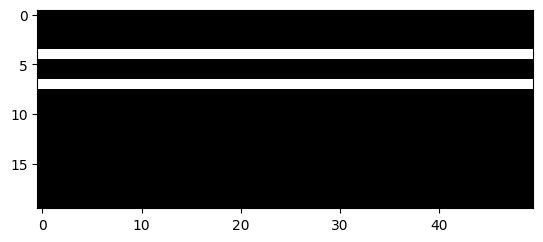

[y = 0.0 * x + 4.0, y = 0.0 * x + 7.0]


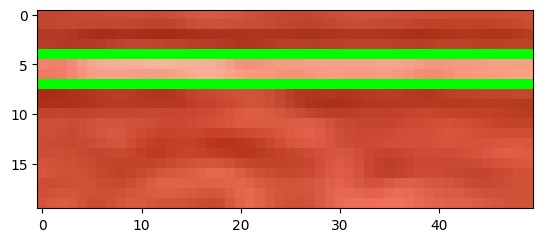

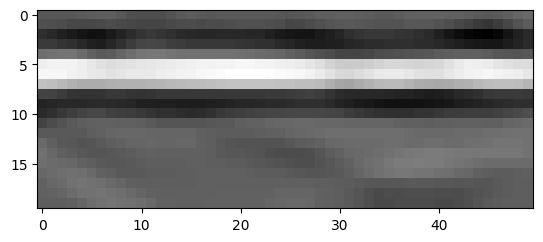

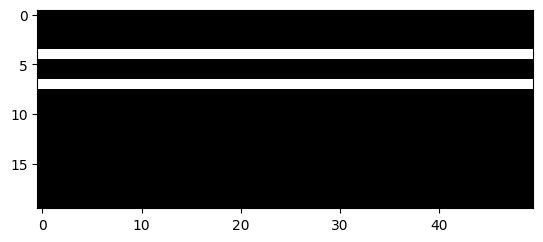

[y = 0.0 * x + 4.0, y = 0.0 * x + 7.0]


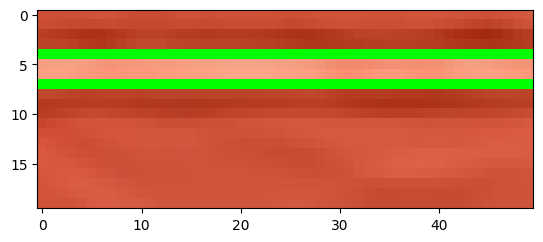

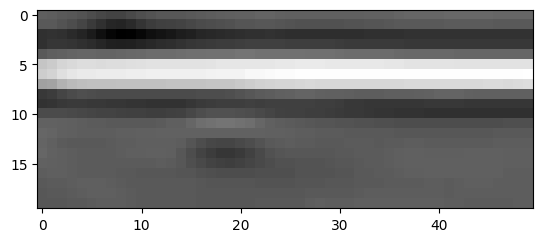

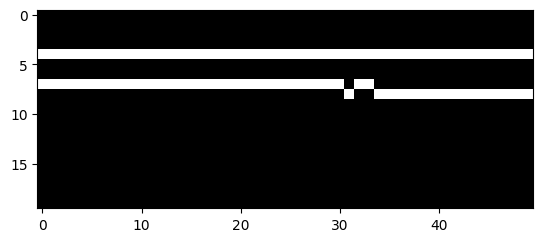

[y = 0.0 * x + 4.0, y = 0.0 * x + 7.0]


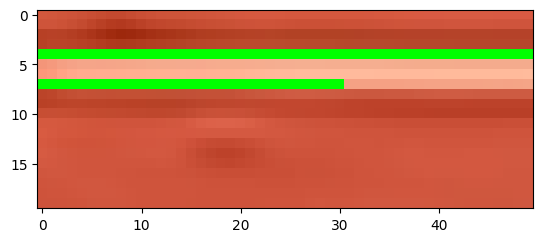

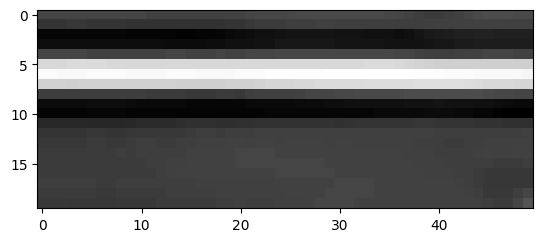

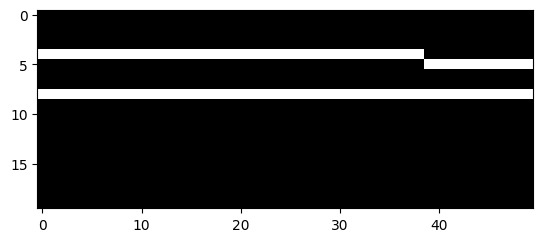

[y = 0.0 * x + 4.0, y = 0.0 * x + 8.0]


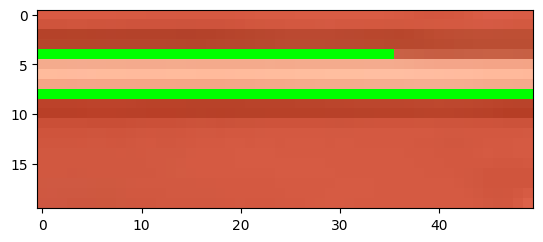

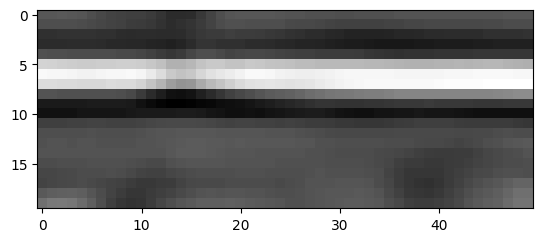

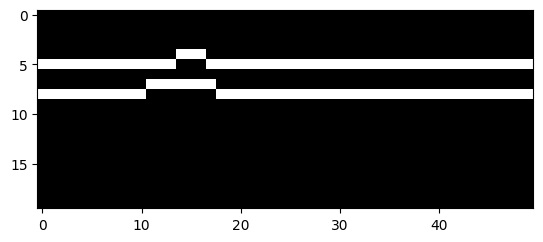

[y = 0.0 * x + 5.0, y = 0.0 * x + 8.0]


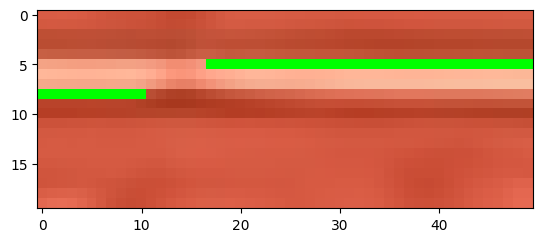

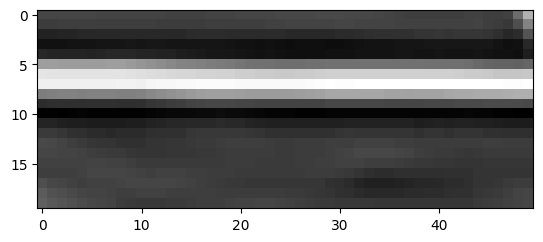

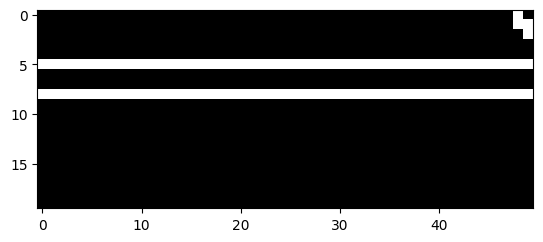

[y = 0.0 * x + 5.0, y = 0.0 * x + 8.0]


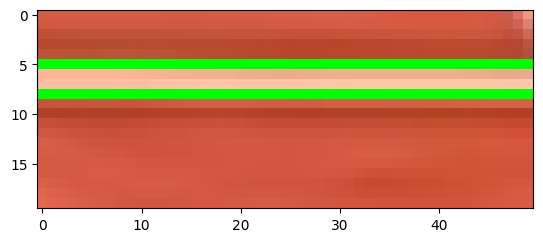

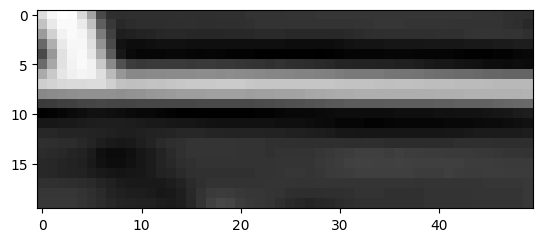

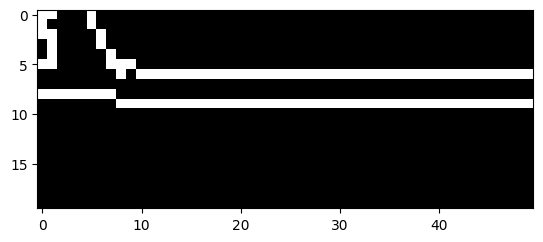

[y = 0.0 * x + 6.0, y = 0.0 * x + 9.0]


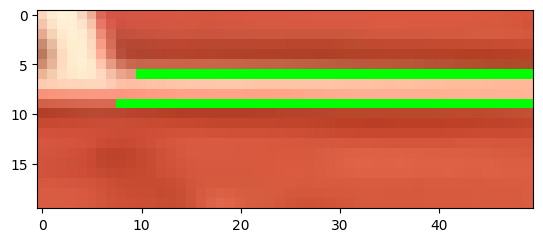

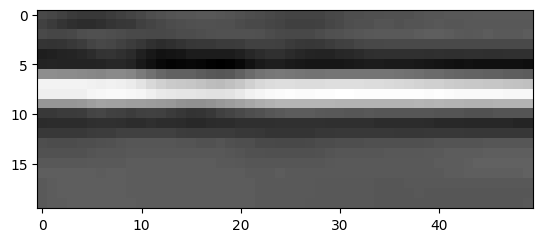

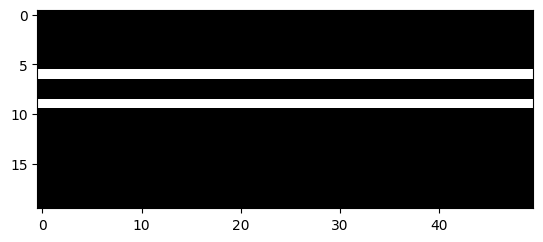

[y = 0.0 * x + 6.0, y = 0.0 * x + 9.0]


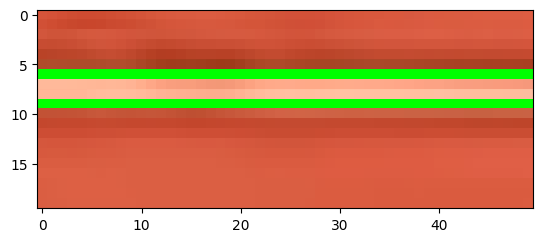

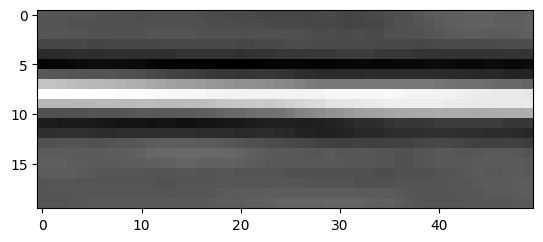

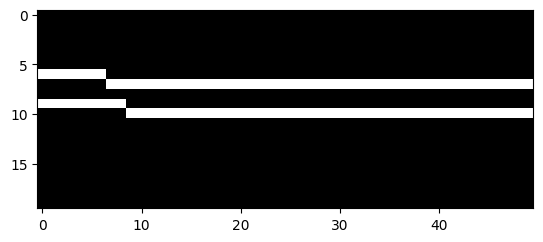

[y = 0.0 * x + 7.0, y = 0.0 * x + 10.0]


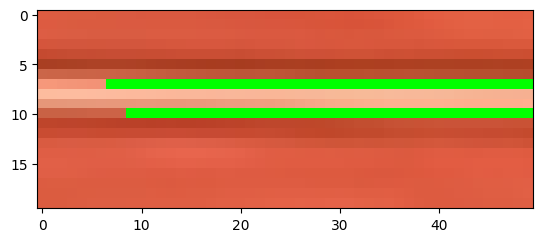

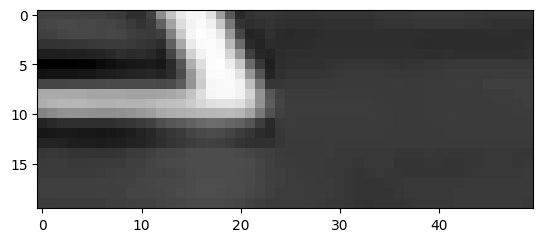

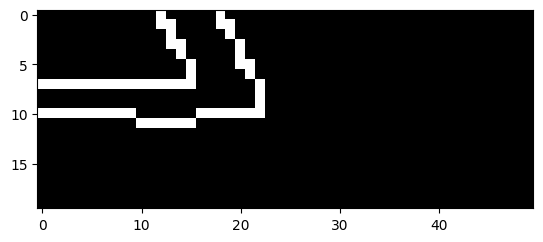

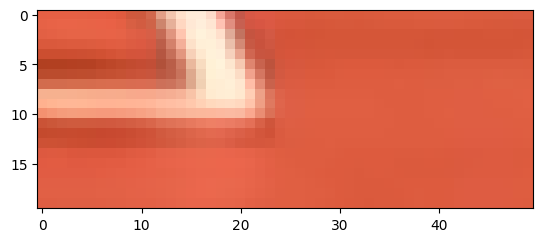

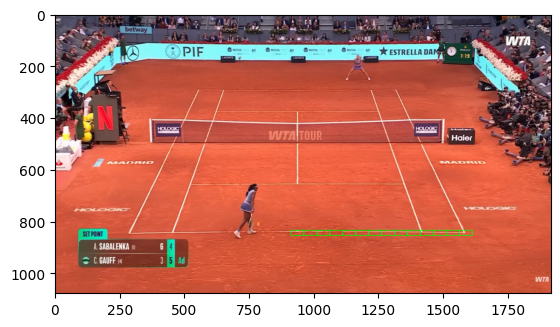

In [59]:
step = 50
x_left = p_c.x
x_right = p_c.x + step
h_delta = 20
img_copy = img.copy()
lines = []
while x_left < right_point.x:

    crop = img[p_c.y - 10: p_c.y + 10, x_left: x_right]
    crop_gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)



    edges = cv2.Canny(crop_gray, 100, 200)
    segments = cv2.HoughLinesP(edges, 1, np.pi / 180, int(step * 0.8), int(step * 0.4), int(step * 0.1))

    display_img(crop_gray)

    display_img(edges)

    crop_copy = crop.copy()
    sub_lines = []
    if segments is not None:
        for line in segments:
            x1, y1, x2, y2 = line[0]
            cv2.line(crop_copy, (x1, y1), (x2, y2), (0, 255, 0), 1)
            line = Line.from_hough_segment(line[0])
            sub_lines.append(line)
    
    # wez lienie horyzontalne
    sub_lines = filter_horizontal_lines(sub_lines)
    if sub_lines:
        print(sorted(sub_lines, key = lambda line: line.intercept))
        bottom_line = sorted(sub_lines, key = lambda line: line.intercept)[-1]
        bottom_line_global = transform_line(bottom_line, crop, x_left, p_c.y)
        lines.append(bottom_line_global)
    else:
        lines.append(None)


    display_img(crop_copy)

    cv2.rectangle(img_copy, (x_left, p_c.y - 10), (x_right, p_c.y + 10), (0, 255, 0), 2)

    x_left = x_right
    x_right += step

display_img(img_copy)

In [60]:
interpolated_right = interpolate_lines_intercept(lines)

In [61]:
interpolated_right

array([852., 849., 849., 852., 852., 852., 852., 853., 853., 853., 854.,
       854., 855., 855.])